In [1]:
import base64
from io import BytesIO

import pandas as pd
import rdkit
from IPython.display import HTML, display
from rdkit import Chem
from rdkit.Chem import Draw, rdDepictor
from stereomolgraph import Bond, StereoMolGraph
from stereomolgraph.algorithms.symmetry import bond_symmetry_number

rdkit.__version__

'2026.03.3'

In [2]:
smiles_bond = [
    ("CC(C)(C)C(CC)(CC)CC", (1, 4)),
    ("CC([C@H](F)C)([C@H](F)C)[C@H](F)C", (0, 1)),
    ("C[C@@H](C([C@@H](C)F)(C)[C@H](C)F)F", (2, 6)),
    ("CCC(CC)(CC)O[H]", (7, 2)),
    ("C[C@H](F)C([C@@H](F)C)([C@@H](F)C)O[H]", (10, 3)),
    ("C[C@H](F)C([C@@H](F)C)([C@H](F)C)O[H]", (10, 3)),
    ("CC1=CC=CC=C1", (0, 1)),
    ("OC1=CC=CC=C1", (0, 1)),
    ("OC12CCC(CC2)CC1", (0, 1)),
    ("OC12C[C@H](C([C@@H](C2)F)[C@@H](C1)F)F", (0, 1)),
    ("OC12C[C@H](C([C@@H](C2)F)[C@H](C1)F)F", (0, 1)),
    ("OC1=CC=C(C2=C(F)C=CC=C2I)C=C1", (0, 1)),
]

image,Bond Symmetry Number,SMILES
,3,CC(C)(C)C(CC)(CC)CC
,3,CC([C@H](F)C)([C@H](F)C)[C@H](F)C
,3,C[C@@H](C([C@@H](C)F)(C)[C@H](C)F)F
,3,CCC(CC)(CC)O[H]
,3,C[C@H](F)C([C@@H](F)C)([C@@H](F)C)O[H]
,1,C[C@H](F)C([C@@H](F)C)([C@H](F)C)O[H]
,6,CC1=CC=CC=C1
,2,OC1=CC=CC=C1
,3,OC12CCC(CC2)CC1
,3,OC12C[C@H](C([C@@H](C2)F)[C@@H](C1)F)F

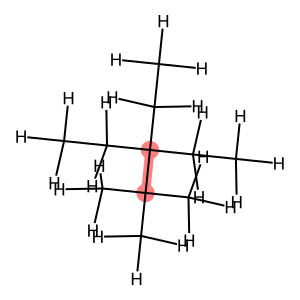
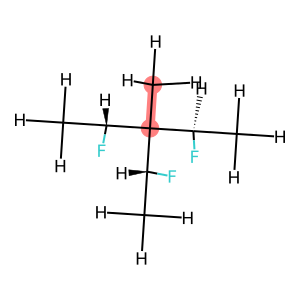
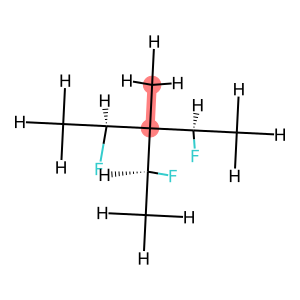
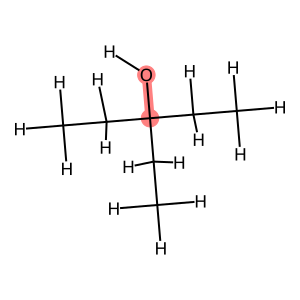
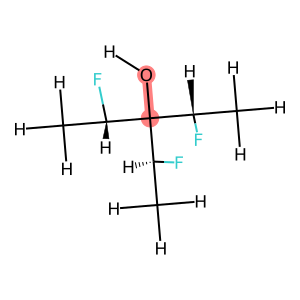
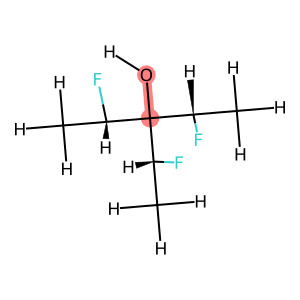
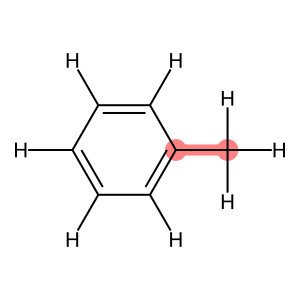
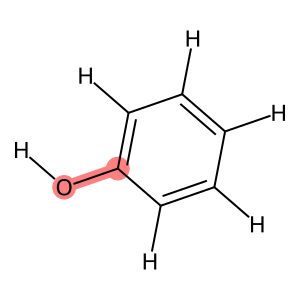
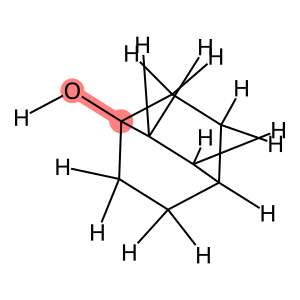
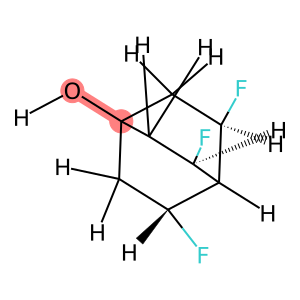
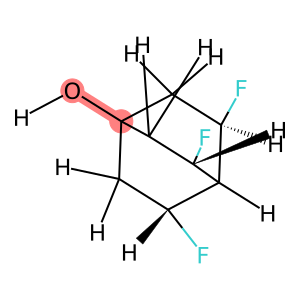
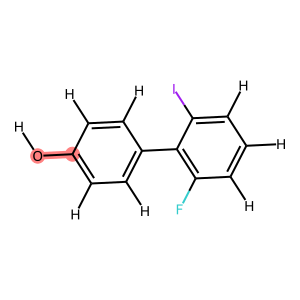
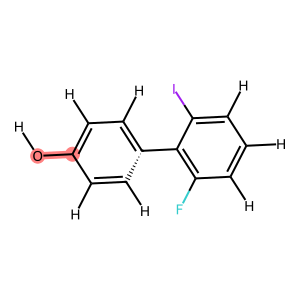

Saved HTML report to: C:\Users\maxim\Code\experiments\SI_SymmetryNumbers\reports\bond_symmetry.html


In [ ]:
from pathlib import Path

from stereomolgraph.stereodescriptors import AtropBond


def rdmol_with_h(smiles: str) -> Chem.Mol:
    mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
    rdDepictor.Compute2DCoords(mol)
    return mol


def mol_image(rdmol: Chem.Mol, bond: Bond):
    """Return a PIL image of the molecule with the given bond highlighted."""
    draw_mol = Chem.Mol(rdmol)
    rdDepictor.Compute2DCoords(draw_mol)
    highlight_bond = draw_mol.GetBondBetweenAtoms(*bond)
    if highlight_bond is None:
        raise ValueError(f"Bond {tuple(sorted(bond))} not found in molecule")
    return Draw.MolToImage(
        draw_mol,
        size=(300, 300),
        highlightAtoms=list(bond),
        highlightBonds=[highlight_bond.GetIdx()],
    )


def _pil_to_html(img) -> str:
    buf = BytesIO()
    img.save(buf, format="PNG")
    b64 = base64.b64encode(buf.getvalue()).decode("ascii")
    return f'<img src="data:image/png;base64,{b64}" width="{img.width}" />'


def result_row(
    smiles: str, bond: Bond, rdmol: Chem.Mol, smg: StereoMolGraph
) -> dict[str, object]:
    return {
        "image": mol_image(rdmol, bond),
        "Bond Symmetry Number": bond_symmetry_number(smg, bond),
        "SMILES": smiles,
    }


rows = []
for smiles, bond in smiles_bond:
    bond = Bond(bond)
    rdmol = rdmol_with_h(smiles)
    smg = StereoMolGraph.from_rdmol(rdmol, stereo_complete=True)
    rows.append(result_row(smiles, bond, rdmol, smg))

atrop_smiles = "OC1=CC=C(C2=C(F)C=CC=C2I)C=C1"
atrop_smg = StereoMolGraph.from_rdmol(
    rdmol_with_h(atrop_smiles),
    stereo_complete=True,
    resonance=False,
    lone_pair_stereo=False,
    use_atom_map_number=False,
)
atrop_smg.set_bond_stereo(AtropBond((3, 13, 4, 5, 6, 11), 1))
atrop_rdmol = atrop_smg.to_rdmol()
rdDepictor.Compute2DCoords(atrop_rdmol)
rows.append(result_row("", Bond((0, 1)), atrop_rdmol, atrop_smg))

results = pd.DataFrame(rows)

# --- Display in notebook ---
display_df = results.copy()
display_df["image"] = display_df["image"].apply(_pil_to_html)
table_html = display_df.to_html(index=False, escape=False)
display(HTML(table_html))

# --- Save as HTML report ---
project_root = next(
    candidate
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (candidate / "pyproject.toml").exists()
)
html_path = project_root / "reports" / "bond_symmetry.html"
html_path.parent.mkdir(parents=True, exist_ok=True)
html_doc = (
    "<!DOCTYPE html><html lang='en'><head><meta charset='utf-8'>"
    "<title>Bond Symmetry Report</title></head><body>"
    f"<div style='overflow-x:auto'>{table_html}</div></body></html>"
)
html_path.write_text(html_doc, encoding="utf-8")
print(f"Saved HTML report to: {html_path.resolve()}")